In [3]:
import json
import csv
import os
import glob

def extract_survey_data():
    survey_data = []
    
    for i in range(1, 7):
        log_file = f"log/Study2-P{i}.log"
        with open(log_file, 'r', encoding='utf-8') as f:
            for line in f:
                if 'system_survey_completed' in line:
                    try:
                        # Extract JSON part after the timestamp and log level
                        json_start = line.find('{"timestamp"')
                        if json_start != -1:
                            json_data = json.loads(line[json_start:])
                            details = json_data.get('details', {})
                            responses = details.get('responses', {})
                            
                            # Add metadata
                            row_data = {
                                'timestamp': json_data.get('timestamp'),
                                'user_id': details.get('user_id'),
                                'session_id': details.get('session_id'),
                                'system_type': details.get('system_type'),
                                'language': details.get('language'),
                                'completion_time': details.get('completion_time'),
                                'system_usage_duration': details.get('system_usage_duration'),
                                'additional_feedback': details.get('additional_feedback', '')
                            }
                            
                            # Add all response items
                            row_data.update(responses)
                            survey_data.append(row_data)
                            
                    except json.JSONDecodeError:
                        continue
    
    # Write to CSV
    if survey_data:
        fieldnames = list(survey_data[0].keys())
        with open('./survey_responses_study2.csv', 'w', newline='', encoding='utf-8') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(survey_data)
        
        print(f"Extracted {len(survey_data)} survey responses to survey_responses.csv")
    else:
        print("No survey data found")
extract_survey_data()

Extracted 6 survey responses to survey_responses.csv


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 불러오기
df = pd.read_csv("result/survey/survey_responses_study2.csv")

likert_cols = [
    "mental_demand","temporal_demand","performance","effort","frustration",
    "exploration","engagement","effort_reward","transparency","expressiveness",
    "dg1_clarity","dg2_prompt_to_image","dg2_image_to_prompt",
    "dg3_reusability","dg3_selective_edit"
 ]

plt.rcParams['font.family'] = 'AppleGothic'  # 한글 폰트 예시
plt.rcParams['font.size'] = 10

def plot_likert_responses(likert_cols, title="Likert Responses by System"):
    reverse_items = ["mental_demand", "temporal_demand", "effort", "frustration"]

    # long-format 변환
    likert_long = df.melt(
        id_vars="system_type", value_vars=likert_cols,
        var_name="question", value_name="response"
    )
    likert_long["response"] = pd.to_numeric(likert_long["response"], errors="coerce")

    # 분포 집계
    likert_counts = (
        likert_long.groupby(["system_type","question","response"])
        .size().reset_index(name="count")
    )
    likert_counts["percent"] = likert_counts.groupby(
        ["system_type","question"]
    )["count"].transform(lambda x: x / x.sum() * 100)

    # 1~7 고정 팔레트 (1=빨강, 7=진초록)
    palette = ["#8b0000","#cd5c5c","#f4cccc","#f2f2f2","#d9ead3","#6aa84f","#274e13"]

    fig, axes = plt.subplots(len(likert_cols), 1, figsize=(8, 0.6*len(likert_cols)), sharex=True)

    for i, q in enumerate(likert_cols):
        ax = axes[i]
        bottoms = {"Baseline": 0.0, "OOPT": 0.0}

        # 항상 1~7을 순회 → 색 고정
        for resp in range(1, 8):
            # 역문항은 색을 뒤집어 매핑
            if q in reverse_items:
                color = palette[7 - resp]      # 1→index6(진초록), 7→index0(진빨강)
                for sys in ["OOPT"]:
                    val = likert_counts.query(
                        "system_type == @sys and question == @q and response == @resp"
                    )["percent"]
                    val = float(val.iloc[0]) if not val.empty else 0.0
                    # 오른쪽→왼쪽 누적
                    ax.barh(f"{sys} ({q})", val, left=100 - bottoms[sys] - val, color=color)
                    if val > 0:
                        ax.text(100 - bottoms[sys] - val/2, f"{sys} ({q})",
                                str(resp), va='center', ha='center', fontsize=8)
                    bottoms[sys] += val
            else:
                color = palette[resp - 1]      # 1→index0(진빨강), 7→index6(진초록)
                for sys in ["OOPT"]:
                    val = likert_counts.query(
                        "system_type == @sys and question == @q and response == @resp"
                    )["percent"]
                    val = float(val.iloc[0]) if not val.empty else 0.0
                    ax.barh(f"{sys} ({q})", val, left=bottoms[sys], color=color)
                    if val > 0:
                        ax.text(bottoms[sys] + val/2, f"{sys} ({q})",
                                str(resp), va='center', ha='center', fontsize=8)
                    bottoms[sys] += val

        ax.set_ylabel("")

    axes[-1].set_xlabel("Percentage (%)")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


In [53]:
TLX_likert_cols = [
    "mental_demand","temporal_demand","performance","effort","frustration",
]

CSI_likert_cols = [
     "exploration","engagement","effort_reward","transparency","expressiveness",
]

Sys_likert_cols = [
    "dg1_clarity","dg2_prompt_to_image","dg2_image_to_prompt",
    "dg3_reusability","dg3_selective_edit"
]


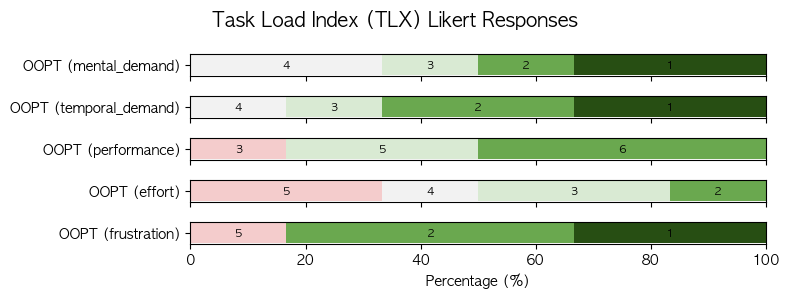

In [54]:
plot_likert_responses(TLX_likert_cols, "Task Load Index (TLX) Likert Responses")

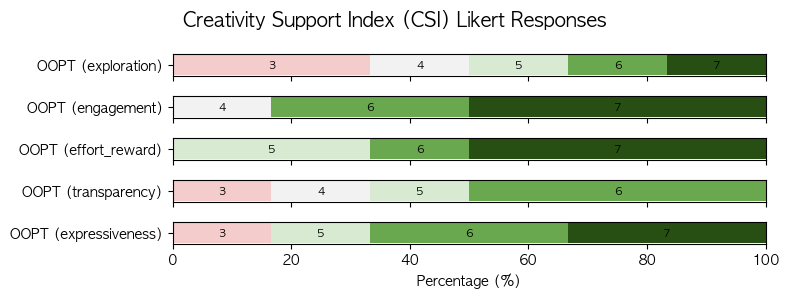

In [55]:
plot_likert_responses(CSI_likert_cols, "Creativity Support Index (CSI) Likert Responses")

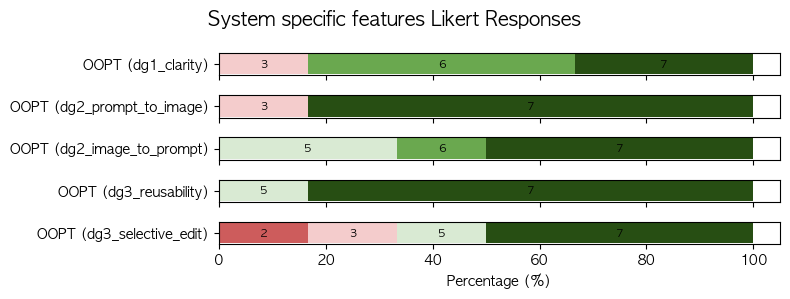

In [56]:
plot_likert_responses(Sys_likert_cols, "System specific features Likert Responses")

In [24]:
import numpy as np

def survey_boot_ci(likert_cols):
    reverse_items = {"mental_demand","temporal_demand","effort","frustration"}

    def orient_scores(s, name):
        v = pd.to_numeric(s, errors="coerce")
        return 8 - v if name in reverse_items else v

    X = df.copy()
    for c in likert_cols:
        X[c] = orient_scores(X[c], c)

    # 부트스트랩 CI
    def boot_ci(x, n=3000, alpha=0.05):
        x = pd.to_numeric(x, errors="coerce").dropna().values
        if len(x)==0: return (np.nan, np.nan)
        boots = np.random.choice(x, (n, len(x)), True).mean(axis=1)
        return np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])

    means = X.groupby("system_type")[likert_cols].mean().T
    cis = {sys: X[X.system_type==sys][likert_cols].apply(lambda col: boot_ci(col), axis=0)
        for sys in ["OOPT"]}

    y = np.arange(len(likert_cols))
    plt.figure(figsize=(9, 0.6*len(likert_cols)))
    color_map = {"Baseline": "#1f77b4", "OOPT": "#ff7f0e"}
    for i,q in enumerate(likert_cols):
        m2 =  means.loc[q, "OOPT"]
        c2 = cis["OOPT"][q]
        # CI
        # plt.plot(c1, [y[i]]*2, lw=4, solid_capstyle="round", color=color_map["Baseline"] + '4D')
        plt.plot(c2, [y[i]]*2, lw=4, solid_capstyle="round", color=color_map["OOPT"] + '4D')
        # mean 점
        # plt.scatter([m1], [y[i]], s=36, zorder=3, color=color_map["Baseline"])
        plt.scatter([m2], [y[i]], s=36, zorder=3, color=color_map["OOPT"])
        # 덤벨 연결선
        # plt.plot([m1, m2], [y[i], y[i]], color="#666", lw=1)

    plt.yticks(y, likert_cols)
    plt.xlabel("Mean score (higher is better)")
    # legend: 색상과 시스템명 직접 표시, 차트 오른쪽 바깥에 위치
    import matplotlib.lines as mlines
    handles = [
        mlines.Line2D([], [], color=color_map["Baseline"], marker='o', linestyle='None', markersize=8, label='Baseline'),
        mlines.Line2D([], [], color=color_map["OOPT"], marker='o', linestyle='None', markersize=8, label='OOPT'),
    ]
    plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
    plt.xlim(1,7)
    plt.tight_layout(); plt.show()


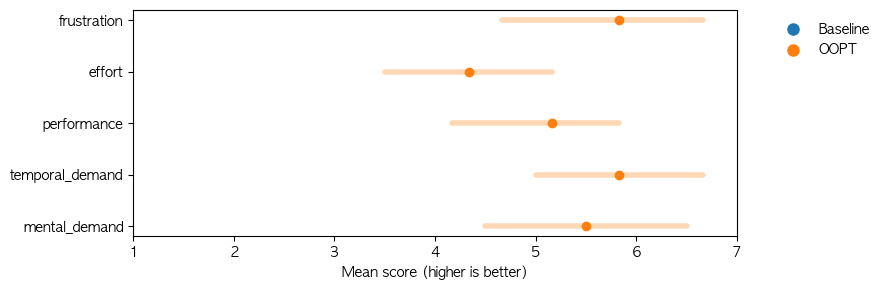

In [25]:
survey_boot_ci(TLX_likert_cols)

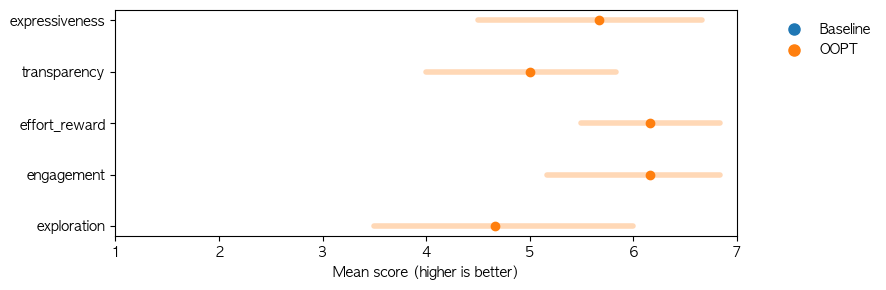

In [26]:
survey_boot_ci(CSI_likert_cols)

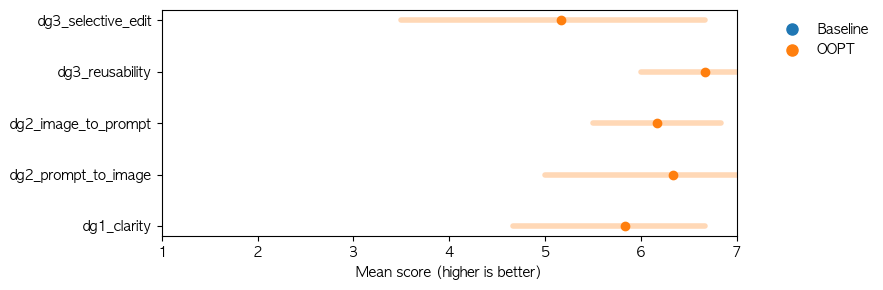

In [27]:
survey_boot_ci(Sys_likert_cols)

In [44]:

from scipy import stats
import numpy as np

def calculate_and_print_p_values(likert_cols, title):
    """
    Calculates and prints p-values for given likert scale columns 
    by comparing 'Baseline' and 'OOPT' system types.
    """
    reverse_items = {"mental_demand", "temporal_demand", "effort", "frustration"}

    def orient_scores(series, name):
        # Re-orient scores where lower is better
        values = pd.to_numeric(series, errors='coerce')
        if name in reverse_items:
            return 8 - values
        return values

    # Prepare a dataframe with oriented scores
    oriented_df = df.copy()
    for col in likert_cols:
        oriented_df[col] = orient_scores(df[col], col)

    # --- Perform t-tests and store results ---
    p_value_results = []
    for question in likert_cols:
        
        # Extract data for each system, dropping any missing values
        baseline_scores = oriented_df[oriented_df['system_type'] == 'Baseline'][question].dropna()
        oopt_scores = oriented_df[oriented_df['system_type'] == 'OOPT'][question].dropna()

        # Perform independent t-test (Welch's t-test, as sample sizes/variances may differ)
        if len(baseline_scores) > 1 and len(oopt_scores) > 1:
            t_stat, p_val = stats.ttest_ind(baseline_scores, oopt_scores, equal_var=False)
            p_value_results.append((question, t_stat, p_val))

    # --- Display results in a formatted table ---
    if p_value_results:
        results_df = pd.DataFrame(p_value_results, columns=['Question', 'T-Statistic', 'P-Value'])
        print(f"--- {title} ---")
        print(results_df.to_string(index=False))
    else:
        print(f"Could not compute p-values for {title}. Not enough data.")

# --- Run the analysis for each category of questions ---
print("P-Value Calculation (Independent T-Test: Baseline vs. OOPT)\\n")

calculate_and_print_p_values(TLX_likert_cols, "Task Load Index (TLX)")
print("\\n")
calculate_and_print_p_values(CSI_likert_cols, "Creativity Support Index (CSI)")
print("\\n")
calculate_and_print_p_values(Sys_likert_cols, "System-Specific Features")


P-Value Calculation (Independent T-Test: Baseline vs. OOPT)\n
--- Task Load Index (TLX) ---
       Question  T-Statistic  P-Value
  mental_demand     0.119756 0.905892
temporal_demand    -0.870988 0.393564
    performance    -1.193776 0.245362
         effort     0.959027 0.348125
    frustration    -1.224189 0.234378
\n
--- Creativity Support Index (CSI) ---
      Question  T-Statistic  P-Value
   exploration    -3.162278 0.005027
    engagement    -2.777460 0.012398
 effort_reward    -2.184013 0.040654
  transparency    -0.983378 0.336268
expressiveness    -2.859075 0.011110
\n
--- System-Specific Features ---
           Question  T-Statistic      P-Value
        dg1_clarity    -5.157762 1.069208e-04
dg2_prompt_to_image    -7.800366 2.337669e-07
dg2_image_to_prompt    -6.565768 4.074550e-06
    dg3_reusability    -7.731338 3.601092e-06
 dg3_selective_edit    -7.296575 1.678604e-06


In [45]:

from scipy import stats
import numpy as np

def calculate_and_print_p_values(likert_cols, title):
    """
    Calculates and prints p-values for given likert scale columns 
    by comparing 'Baseline' and 'OOPT' system types.
    """
    reverse_items = {"mental_demand", "temporal_demand", "effort", "frustration"}

    def orient_scores(series, name):
        # Re-orient scores where lower is better
        values = pd.to_numeric(series, errors='coerce')
        if name in reverse_items:
            return 8 - values
        return values

    # Prepare a dataframe with oriented scores
    oriented_df = df.copy()
    for col in likert_cols:
        oriented_df[col] = orient_scores(df[col], col)

    # --- Perform t-tests and store results ---
    p_value_results = []
    for question in likert_cols:
        
        # Extract data for each system, dropping any missing values
        baseline_scores = oriented_df[oriented_df['system_type'] == 'Baseline'][question].dropna()
        oopt_scores = oriented_df[oriented_df['system_type'] == 'OOPT'][question].dropna()

        # Perform independent t-test (Welch's t-test, as sample sizes/variances may differ)
        if len(baseline_scores) > 1 and len(oopt_scores) > 1:
            t_stat, p_val = stats.ttest_ind(baseline_scores, oopt_scores, equal_var=False)
            p_value_results.append((question, t_stat, p_val))

    # --- Display results in a formatted table ---
    if p_value_results:
        results_df = pd.DataFrame(p_value_results, columns=['Question', 'T-Statistic', 'P-Value'])
        print(f"--- {title} ---")
        print(results_df.to_string(index=False))
    else:
        print(f"Could not compute p-values for {title}. Not enough data.")

# --- Run the analysis for each category of questions ---
print("P-Value Calculation (Independent T-Test: Baseline vs. OOPT)\\n")

calculate_and_print_p_values(TLX_likert_cols, "Task Load Index (TLX)")
print("\\n")
calculate_and_print_p_values(CSI_likert_cols, "Creativity Support Index (CSI)")
print("\\n")
calculate_and_print_p_values(Sys_likert_cols, "System-Specific Features")


P-Value Calculation (Independent T-Test: Baseline vs. OOPT)\n
--- Task Load Index (TLX) ---
       Question  T-Statistic  P-Value
  mental_demand     0.119756 0.905892
temporal_demand    -0.870988 0.393564
    performance    -1.193776 0.245362
         effort     0.959027 0.348125
    frustration    -1.224189 0.234378
\n
--- Creativity Support Index (CSI) ---
      Question  T-Statistic  P-Value
   exploration    -3.162278 0.005027
    engagement    -2.777460 0.012398
 effort_reward    -2.184013 0.040654
  transparency    -0.983378 0.336268
expressiveness    -2.859075 0.011110
\n
--- System-Specific Features ---
           Question  T-Statistic      P-Value
        dg1_clarity    -5.157762 1.069208e-04
dg2_prompt_to_image    -7.800366 2.337669e-07
dg2_image_to_prompt    -6.565768 4.074550e-06
    dg3_reusability    -7.731338 3.601092e-06
 dg3_selective_edit    -7.296575 1.678604e-06


In [46]:

from scipy import stats
import numpy as np

def calculate_and_print_p_values(likert_cols, title):
    """
    Calculates and prints p-values for given likert scale columns 
    by comparing 'Baseline' and 'OOPT' system types.
    """
    reverse_items = {"mental_demand", "temporal_demand", "effort", "frustration"}

    def orient_scores(series, name):
        # Re-orient scores where lower is better
        values = pd.to_numeric(series, errors='coerce')
        if name in reverse_items:
            return 8 - values
        return values

    # Prepare a dataframe with oriented scores
    oriented_df = df.copy()
    for col in likert_cols:
        oriented_df[col] = orient_scores(df[col], col)

    # --- Perform t-tests and store results ---
    p_value_results = []
    for question in likert_cols:
        
        # Extract data for each system, dropping any missing values
        baseline_scores = oriented_df[oriented_df['system_type'] == 'Baseline'][question].dropna()
        oopt_scores = oriented_df[oriented_df['system_type'] == 'OOPT'][question].dropna()

        # Perform independent t-test (Welch's t-test, as sample sizes/variances may differ)
        if len(baseline_scores) > 1 and len(oopt_scores) > 1:
            t_stat, p_val = stats.ttest_ind(baseline_scores, oopt_scores, equal_var=False)
            p_value_results.append((question, t_stat, p_val))

    # --- Display results in a formatted table ---
    if p_value_results:
        results_df = pd.DataFrame(p_value_results, columns=['Question', 'T-Statistic', 'P-Value'])
        print(f"--- {title} ---")
        print(results_df.to_string(index=False))
    else:
        print(f"Could not compute p-values for {title}. Not enough data.")

# --- Run the analysis for each category of questions ---
print("P-Value Calculation (Independent T-Test: Baseline vs. OOPT)\\n")

calculate_and_print_p_values(TLX_likert_cols, "Task Load Index (TLX)")
print("\\n")
calculate_and_print_p_values(CSI_likert_cols, "Creativity Support Index (CSI)")
print("\\n")
calculate_and_print_p_values(Sys_likert_cols, "System-Specific Features")


P-Value Calculation (Independent T-Test: Baseline vs. OOPT)\n
--- Task Load Index (TLX) ---
       Question  T-Statistic  P-Value
  mental_demand     0.119756 0.905892
temporal_demand    -0.870988 0.393564
    performance    -1.193776 0.245362
         effort     0.959027 0.348125
    frustration    -1.224189 0.234378
\n
--- Creativity Support Index (CSI) ---
      Question  T-Statistic  P-Value
   exploration    -3.162278 0.005027
    engagement    -2.777460 0.012398
 effort_reward    -2.184013 0.040654
  transparency    -0.983378 0.336268
expressiveness    -2.859075 0.011110
\n
--- System-Specific Features ---
           Question  T-Statistic      P-Value
        dg1_clarity    -5.157762 1.069208e-04
dg2_prompt_to_image    -7.800366 2.337669e-07
dg2_image_to_prompt    -6.565768 4.074550e-06
    dg3_reusability    -7.731338 3.601092e-06
 dg3_selective_edit    -7.296575 1.678604e-06
